# Synergy ML Task 9.5 — Linear Regression From Scratch

This notebook follows the Task 9.5 requirements for the **regression experiment**.

**Important:** No scikit-learn or ready-made ML model is used. Only NumPy, pandas, and matplotlib are used for data handling, numerical operations, visualization, and evaluation.

### Workflow
1. Load the provided regression dataset.
2. Frame `X` and continuous target `y`.
3. Split into train/validation/test sets using our own implementation.
4. Fit feature-scaling parameters using the training set only.
5. Implement linear regression and batch gradient descent from scratch.
6. Track training and validation loss.
7. Evaluate using MSE, RMSE, MAE, and R².
8. Compare against a mean-target baseline.
9. Inspect the largest prediction errors.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

TARGET_COLUMN = "volume_sales"

df = pd.read_csv(r"C:\Users\Samaira Singh\Synergy_TP\task_9.5\data\oil_sales_assignment_dataset.csv")
print("Shape:", df.shape)
display(df.head())
print(df.info())


Shape: (2000, 13)


,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.2+ KB
None


In [5]:
# Basic data inspection
print("Missing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

print("\nSummary:")
print(df.describe(include="all"))


Missing values:
city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

Data types:
city              object
store_name        object
manufacturer      object
brand             object
class             object
size              object
sku               object
price_bracket     object
year               int64
month              int64
value_sales      float64
volume_sales     float64
average_price    float64
dtype: object

Summary:
           city                                        store_name  \
count      2000                                              2000   
unique       12                                              1997   
top     AL BAHA  HM No  59035  GS-CENTER-AL AHSA MAIN RD  AL AHSA   
freq        199                                                 2   
mean        NaN  

In [7]:
# Prepare X and y

numeric_df = df.select_dtypes(include=[np.number]).copy()

X_df = numeric_df.drop(columns=[TARGET_COLUMN])
y_series = numeric_df[TARGET_COLUMN]
X = X_df.to_numpy(dtype=float)
y = y_series.to_numpy(dtype=float).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2000, 4)
y shape: (2000, 1)


In [8]:
# Our own train/validation/test split
def train_val_test_split(X, y, val_size=0.15, test_size=0.15):
    np.random.seed(42)
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    n_train = int(len(X) * (1 - val_size - test_size))
    n_val = int(len(X) * val_size)
    tr, va, te = idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]

    return X[tr], y[tr], X[va], y[va], X[te], y[te]

X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (1400, 4) (1400, 1)
Validation: (300, 4) (300, 1)
Test: (300, 4) (300, 1)


In [9]:
# Feature scaling: standardization using TRAINING statistics only
def fit_standard_scaler(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std

def transform_standard_scaler(X, mean, std):
    return (X - mean) / std

X_mean, X_std = fit_standard_scaler(X_train)

X_train_s = transform_standard_scaler(X_train, X_mean, X_std)
X_val_s = transform_standard_scaler(X_val, X_mean, X_std)
X_test_s = transform_standard_scaler(X_test, X_mean, X_std)

print("Training feature means after scaling:", X_train_s.mean(axis=0))
print("Training feature stds after scaling:", X_train_s.std(axis=0))


Training feature means after scaling: [9.82423666e-14 2.00157351e-16 6.93849740e-16 1.96826682e-16]
Training feature stds after scaling: [1. 1. 1. 1.]


In [10]:
def predict_linear(X, w, b):
    return X @ w + b

def mse_loss(X, y, w, b):
    y_pred = predict_linear(X, w, b)
    return np.mean((y_pred - y) ** 2) / 2

def linear_gradient_descent(X_train, y_train, X_val, y_val,
                            learning_rate=0.01, iterations=2000):
    m, n = X_train.shape
    w = np.zeros((n, 1))
    b = 0.0

    train_losses = []
    val_losses = []

    for _ in range(iterations):
        y_pred = predict_linear(X_train, w, b)
        error = y_pred - y_train

        dw = (X_train.T @ error) / m
        db = np.mean(error)

        w -= learning_rate * dw
        b -= learning_rate * db

        train_losses.append(mse_loss(X_train, y_train, w, b))
        val_losses.append(mse_loss(X_val, y_val, w, b))

    return w, b, train_losses, val_losses

w, b, train_losses, val_losses = linear_gradient_descent(
    X_train_s, y_train, X_val_s, y_val,
    learning_rate=0.01,
    iterations=2000
)

print("Weights:", w.ravel())
print("Bias:", b)


Weights: [-0.04781575  0.19658768  9.85745569 -3.66744621]
Bias: 9.73435712471467


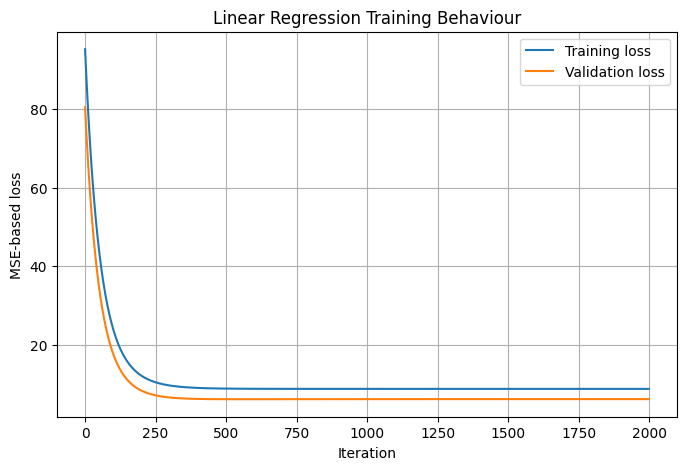

In [11]:
# Loss curve
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Iteration")
plt.ylabel("MSE-based loss")
plt.title("Linear Regression Training Behaviour")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Regression metrics implemented without ML-library functions
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

def regression_report(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred),
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score_manual(y_true, y_pred)
    }

y_train_pred = predict_linear(X_train_s, w, b)
y_val_pred = predict_linear(X_val_s, w, b)
y_test_pred = predict_linear(X_test_s, w, b)

results = pd.DataFrame({
    "Train": regression_report(y_train, y_train_pred),
    "Validation": regression_report(y_val, y_val_pred),
    "Test": regression_report(y_test, y_test_pred)
}).T

display(results)


,MAE,MSE,RMSE,R2
Train,2.612523,17.455897,4.178026,0.823786
Validation,2.263897,12.248475,3.499782,0.823512
Test,2.792090,19.282772,4.391215,0.831239


In [13]:
baseline_value = np.mean(y_train)

baseline_train = np.full_like(y_train, baseline_value)
baseline_val = np.full_like(y_val, baseline_value)
baseline_test = np.full_like(y_test, baseline_value)

baseline_results = pd.DataFrame({
    "Train": regression_report(y_train, baseline_train),
    "Validation": regression_report(y_val, baseline_val),
    "Test": regression_report(y_test, baseline_test)
}).T

print("Mean-target baseline:")
print(baseline_results)

comparison = pd.DataFrame({
    "Linear Regression": regression_report(y_test, y_test_pred),
    "Mean Baseline": regression_report(y_test, baseline_test)
}).T

print(comparison)


Mean-target baseline:
                 MAE         MSE       RMSE        R2
Train       7.214058   99.060984   9.952938  0.000000
Validation  6.473704   69.401433   8.330752 -0.000002
Test        7.826830  116.808730  10.807809 -0.022302
                       MAE         MSE       RMSE        R2
Linear Regression  2.79209   19.282772   4.391215  0.831239
Mean Baseline      7.82683  116.808730  10.807809 -0.022302


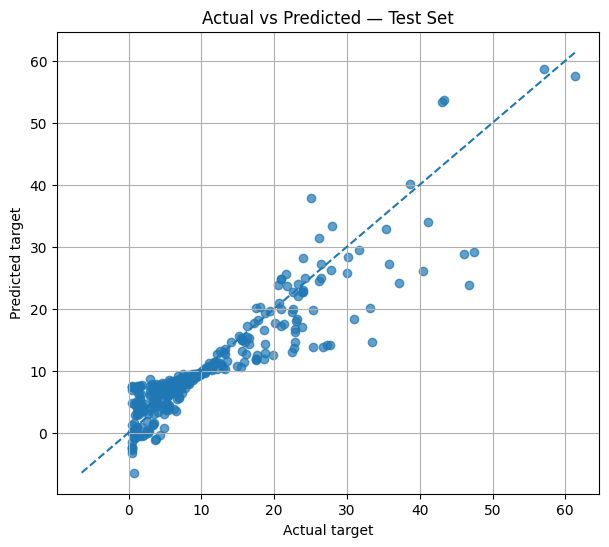

In [14]:
# Actual vs predicted
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.7)

low = min(y_test.min(), y_test_pred.min())
high = max(y_test.max(), y_test_pred.max())
plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Actual vs Predicted — Test Set")
plt.grid(True)
plt.show()


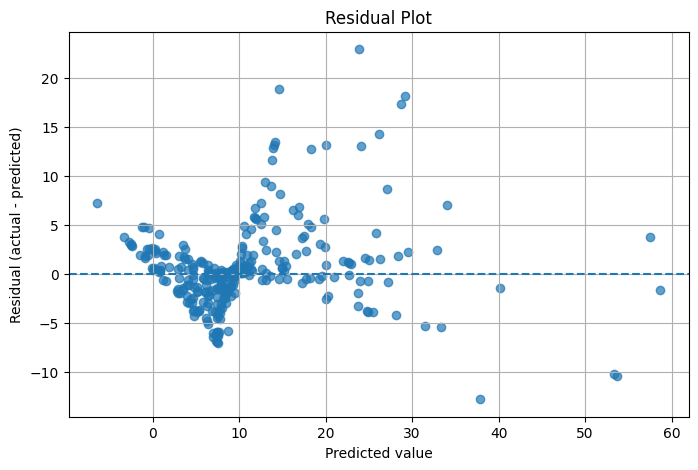

Largest regression errors:
     Actual  Predicted   Residual  Absolute_Error
49     46.8  23.848791  22.951209       22.951209
43     33.5  14.640871  18.859129       18.859129
85     47.4  29.178109  18.221891       18.221891
280    46.1  28.745332  17.354668       17.354668
182    40.4  26.146125  14.253875       14.253875
159    27.7  14.189371  13.510629       13.510629
14     33.2  20.062136  13.137864       13.137864
64     27.2  14.062833  13.137167       13.137167
237    37.1  24.080985  13.019015       13.019015
6      26.7  13.874004  12.825996       12.825996


In [16]:
# Residual analysis
residuals = y_test.ravel() - y_test_pred.ravel()

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred.ravel(), residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

error_table = pd.DataFrame({
    "Actual": y_test.ravel(),
    "Predicted": y_test_pred.ravel(),
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
}).sort_values("Absolute_Error", ascending=False)

print("Largest regression errors:")
print(error_table.head(10))
